In [135]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [136]:
# --- Load dataset ---
# Example format:
# Columns: Species, temp_1, temp_2,..., temp_n
# Rows: Arabian smooth-hound, 0.01527, 0.01518,...
data = pd.read_csv("shark_dataset.csv")

# --- Features = Fluorescence values, Label = Species ---
X_raw = data.drop(columns=["Species"])
y = data["Species"]

# --- Drop species with <2 samples to allow stratification ---
counts = y.value_counts()
valid_classes = counts[counts >= 2].index
mask = y.isin(valid_classes)
X_raw = X_raw[mask]
y = y[mask]


In [137]:
# --- Feature engineering ---

from scipy.integrate import simpson

def feature_engineering(df):
    features = pd.DataFrame()
    temps = df.columns.astype(float)

    features['max'] = df.max(axis=1)
    features['min'] = df.min(axis=1)
    features['mean'] = df.mean(axis=1)
    features['std'] = df.std(axis=1)
    
    features['auc'] = df.apply(lambda row: simpson(row, temps), axis=1)
    features['centroid'] = df.apply(lambda row: np.sum(row*temps)/np.sum(row), axis=1)
    
    features['temp_peak'] = df.apply(lambda row: temps[np.argmax(row)], axis=1)
    features['fwhm'] = df.apply(lambda row: np.sum(row > 0.5*row.max()), axis=1)
    features['rise_time'] = df.apply(lambda row: np.argmax(row), axis=1)
    features['decay_time'] = df.apply(lambda row: len(row) - np.argmax(row[::-1]), axis=1)
    
    features['auc_left'] = df.apply(lambda row: simpson(row[:np.argmax(row)+1], temps[:np.argmax(row)+1]), axis=1)
    features['auc_right'] = df.apply(lambda row: simpson(row[np.argmax(row):], temps[np.argmax(row):]), axis=1)
    
    features['asymmetry'] = features['auc_left'] / (features['auc_right'] + 1e-8)
    return features

X_features = feature_engineering(X_raw)

def enhanced_features(features):
    enhanced = features.copy()
    
    # Interaction features from top performers
    enhanced['fwhm_rise_ratio'] = features['fwhm'] / (features['rise_time'] + 1e-8)
    enhanced['peak_temp_std'] = features['temp_peak'] * features['std']
    enhanced['asymmetry_fwhm'] = features['asymmetry'] * features['fwhm']
    enhanced['rise_decay_ratio'] = features['rise_time'] / (features['decay_time'] + 1e-8)
    
    return enhanced

X_features = enhanced_features(X_features)

In [138]:
# --- Train/test split with stratification (keeps species balanced across sets) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,   # number of trees
    max_depth=None,     # fully expanded trees
    random_state=42,
    n_jobs=-1           # use all CPU cores
)

rf.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [139]:
# --- Hyperparameter tuning ---
param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 15, 20, 25],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": ["balanced", "balanced_subsample", None]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# --- Best Random Forest ---
best_rf = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)
print("Best cross-val score:", grid_search.best_score_)


# --- Train best model on full train set ---
best_rf.fit(X_train, y_train)
y_test_pred_check = best_rf.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_test_pred_check))
print("Difference (CV - Test):", grid_search.best_score_ - accuracy_score(y_test, y_test_pred_check))


c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best parameters: {'class_weight': 'balanced', 'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best cross-val score: 0.8653846153846153
Test accuracy: 0.8931297709923665
Difference (CV - Test): -0.02774515560775115


In [150]:
# --- Predictions on test set ---
sample_idx = np.random.choice(X_test.index, size=5, replace=False)
for idx in sample_idx:
    probs = best_rf.predict_proba([X_test.loc[idx]])[0]
    sorted_idx = np.argsort(probs)[::-1]
    
    print(f"Row {idx} | True: {y_test.loc[idx]} | Pred: {best_rf.classes_[sorted_idx[0]]} ({probs[sorted_idx[0]]*100:.1f}%)")
    for i in sorted_idx[:5]:
        print(f"  {best_rf.classes_[i]:<25} {probs[i]*100:.3f}%")
    print()

Row 471 | True: Sandtiger shark | Pred: Sandtiger shark (87.5%)
  Sandtiger shark           87.475%
  Common thresher shark     5.499%
  Halavi guitarfish         2.290%
  Shortfin mako             1.568%
  Finetooth shark           0.954%

Row 531 | True: Silky shark | Pred: Silky shark (90.1%)
  Silky shark               90.081%
  Oceanic whitetip shark    2.338%
  Porbeagle shark           1.561%
  Dusky shark               1.250%
  Grey reef shark           1.135%

Row 586 | True: Spotted Eagleray | Pred: Spotted Eagleray (100.0%)
  Spotted Eagleray          100.000%
  Zebra shark               0.000%
  Whitecheeck shark         0.000%
  Tiger shark               0.000%
  Tope shark                0.000%

Row 468 | True: Sandtiger shark | Pred: Sandtiger shark (89.3%)
  Sandtiger shark           89.252%
  Common thresher shark     2.871%
  Finetooth shark           1.921%
  Halavi guitarfish         1.455%
  Thornback ray             1.250%

Row 524 | True: Silky shark | Pred: Silk

c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\skl

In [141]:
# --- Evaluation ---
y_test_pred = best_rf.predict(X_test)
print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


Test Accuracy: 0.8931297709923665

Classification Report:
                             precision    recall  f1-score   support

      Arabian smooth-hound       0.00      0.00      0.00         1
  Atlantic Sharpnose shark       1.00      1.00      1.00         1
      Blackchin guitarfish       1.00      1.00      1.00         2
           Blacknose shark       1.00      1.00      1.00         1
 Blackspotted smooth-hound       0.00      0.00      0.00         1
       Blacktip reef shark       1.00      1.00      1.00         1
            Blacktip shark       0.83      0.83      0.83         6
                Blue shark       1.00      0.86      0.92         7
          Bonnethead shark       1.00      1.00      1.00         1
       Bowmouth guitarfish       1.00      1.00      1.00         1
  Brownbanded bamboo shark       1.00      0.50      0.67         2
                Bull shark       1.00      1.00      1.00         6
      Caribbean reef shark       1.00      1.00      1.

c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

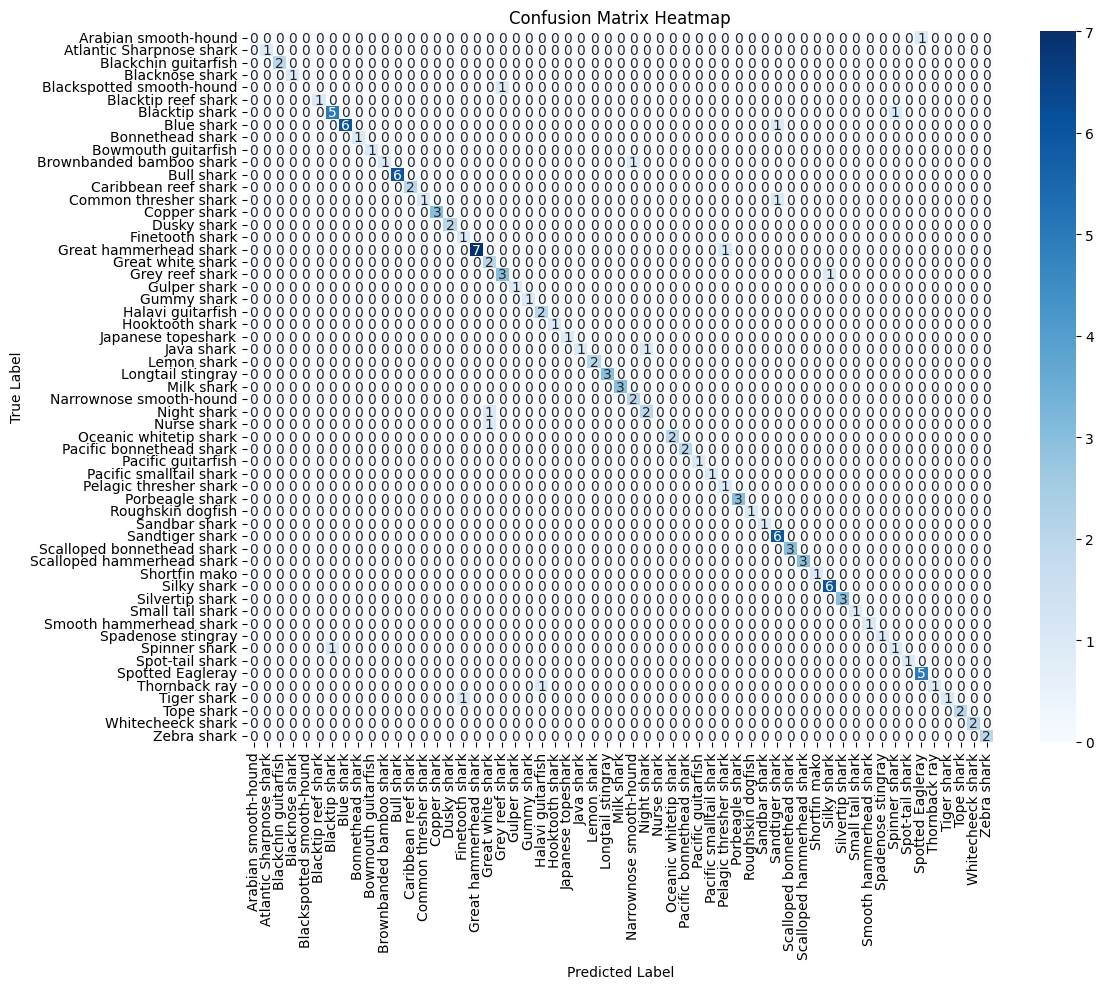

In [142]:
# --- Confusion matrix for species-level performance ---
cm = confusion_matrix(y_test, y_test_pred, labels=best_rf.classes_)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_rf.classes_, yticklabels=best_rf.classes_)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix Heatmap")
plt.tight_layout()
plt.show()

In [143]:
# --- Feature importance ---
importances = pd.Series(best_rf.feature_importances_, index=X_features.columns)
print("\nTop 10 Important Features:\n", importances.nlargest(10))

# Feature Selection
print("\n--- Testing with Feature Selection ---")
top_n = 8  # experiment with 6, 8, 10
top_features = importances.nlargest(top_n).index
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

# Retrain with selected features
rf_selected = RandomForestClassifier(**grid_search.best_params_)
rf_selected.fit(X_train_selected, y_train)
y_pred_selected = rf_selected.predict(X_test_selected)
print(f"Accuracy with top {top_n} features:", accuracy_score(y_test, y_pred_selected))


Top 10 Important Features:
 fwhm_rise_ratio     0.120368
fwhm                0.119453
asymmetry_fwhm      0.096647
asymmetry           0.083692
temp_peak           0.075088
decay_time          0.074532
rise_time           0.071660
rise_decay_ratio    0.057265
max                 0.051736
peak_temp_std       0.049715
dtype: float64

--- Testing with Feature Selection ---
Accuracy with top 8 features: 0.8549618320610687


c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Cross-validation accuracies: [0.86259542 0.87692308 0.83846154 0.86923077 0.85384615]
Mean accuracy: 0.8602113916617734


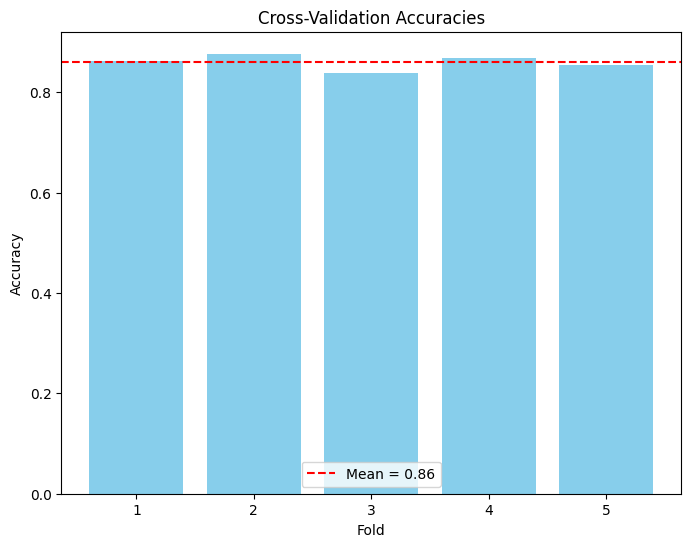

In [144]:
# --- Stratified K-Fold Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(best_rf, X_features, y, cv=cv, scoring='accuracy')

print("Cross-validation accuracies:", scores)
print("Mean accuracy:", scores.mean())
plt.figure(figsize=(8,6))
plt.bar(range(1, len(scores)+1), scores, color="skyblue")
plt.axhline(np.mean(scores), color="red", linestyle="--", label=f"Mean = {scores.mean():.2f}")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracies")
plt.legend()
plt.show()

c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

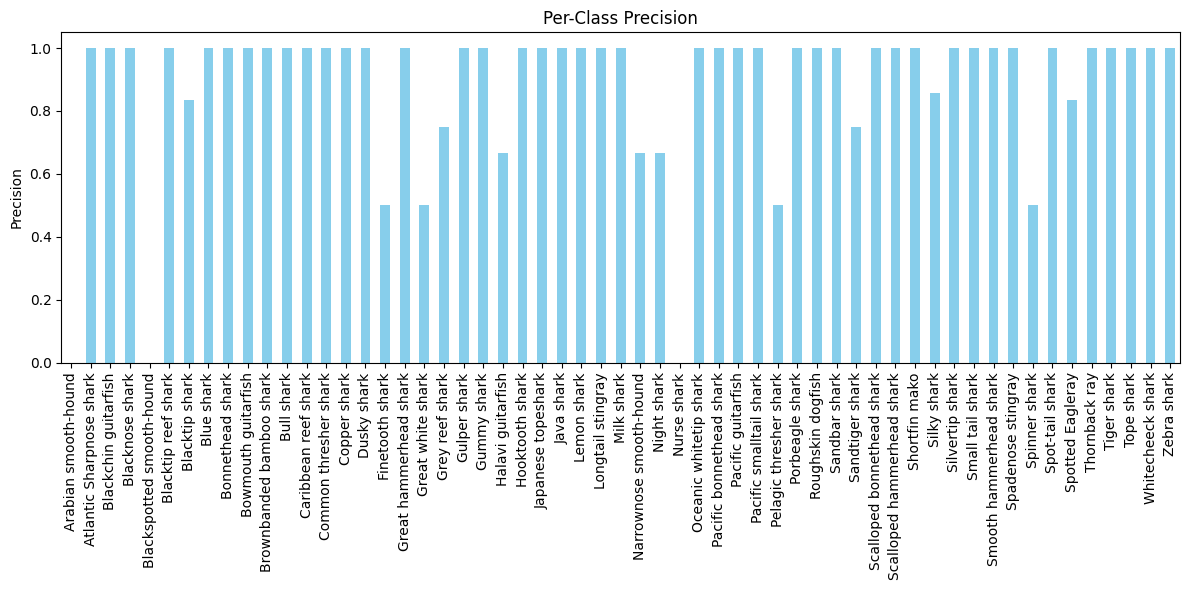

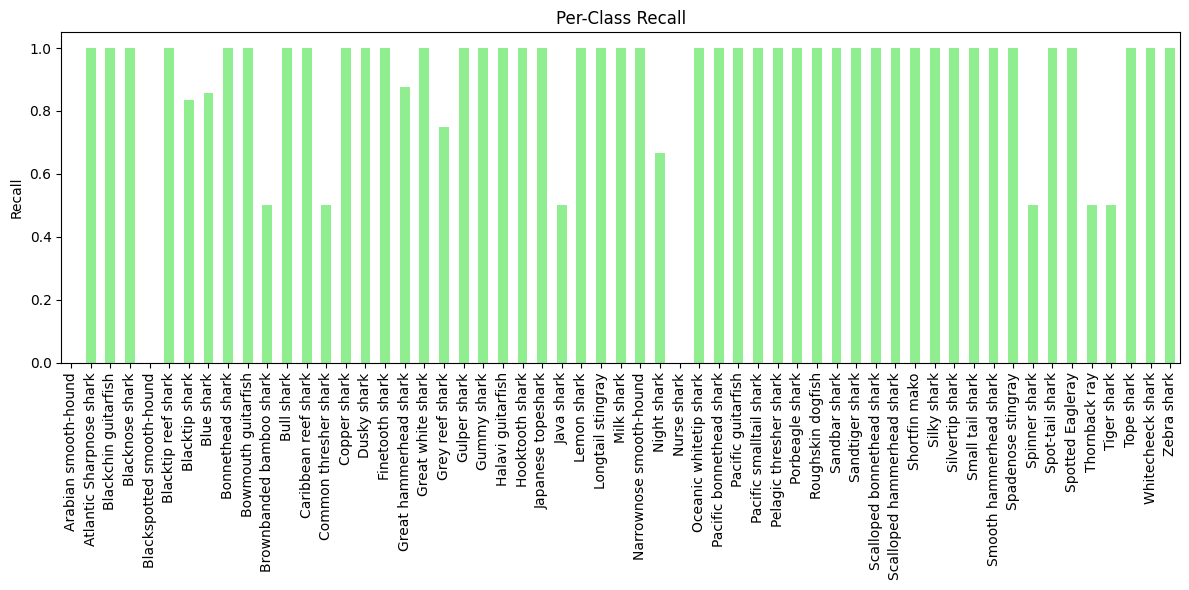

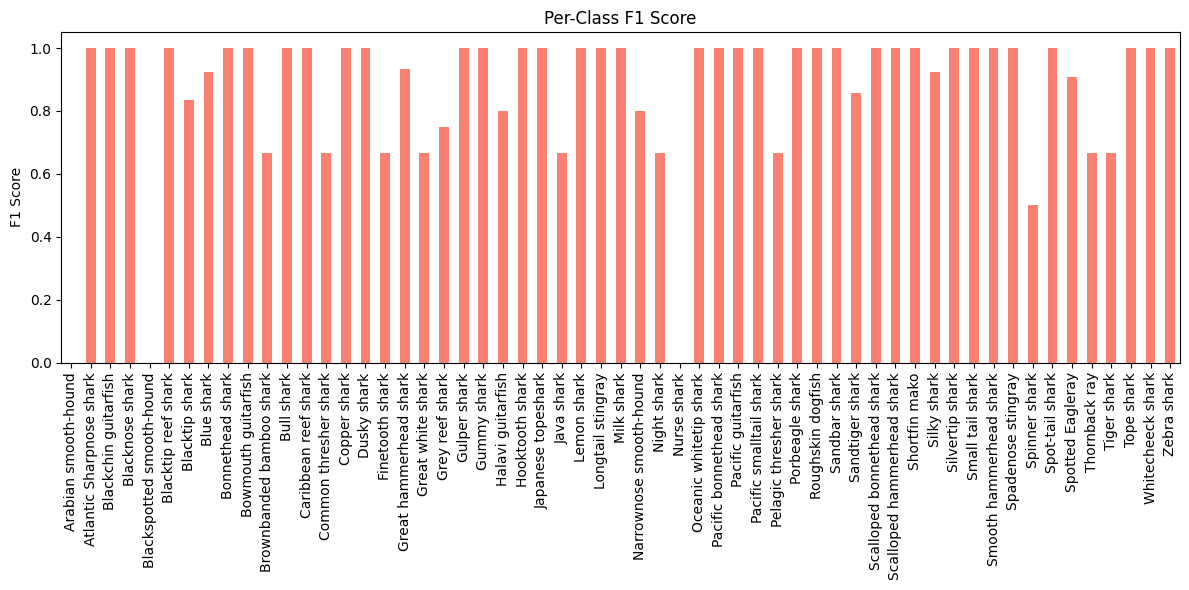

In [145]:
# --- Per-class precision, recall, and F1 ---
report = classification_report(y_test, y_test_pred, output_dict=True)
df = pd.DataFrame(report).transpose().drop(["accuracy", "macro avg", "weighted avg"])
precision = df["precision"]
recall = df["recall"]
f1 = df["f1-score"]

# Plot precision
plt.figure(figsize=(12,6))
precision.plot(kind="bar", color="skyblue")
plt.title("Per-Class Precision")
plt.ylabel("Precision")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Plot recall
plt.figure(figsize=(12,6))
recall.plot(kind="bar", color="lightgreen")
plt.title("Per-Class Recall")
plt.ylabel("Recall")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Plot F1 score
plt.figure(figsize=(12,6))
f1.plot(kind="bar", color="salmon")
plt.title("Per-Class F1 Score")
plt.ylabel("F1 Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()